In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [35]:
# Setup paths (relative to notebook location)
notebook_dir = Path.cwd()
data_dir = notebook_dir.parent / '4_mice'
data_path = data_dir / 'psths_fanofactor_per_neuron_all_regions_18-06-2026'
print(f'Data directory: {data_dir}')
print(f'Data file exists: {data_path.exists()}')

Data directory: /home/ines/repositories/representation_learning_variability/paper-individuality/4_mice
Data file exists: True


In [36]:
# Load neuronal data and rename 'area' to 'Beryl'
summary_df = pd.read_parquet(data_path)
summary_df = summary_df.rename(columns={'area': 'Beryl'})
print(f'Loaded {len(summary_df)} neurons')
print(f'Columns: {list(summary_df.columns)}')
print(f'Brain regions: {summary_df["Beryl"].nunique()}')
print(summary_df.head())

Loaded 65539 neurons
Columns: ['pid', 'session', 'neuron_id', 'Beryl', 'n_trials', 'time_0', 'time_1', 'time_2', 'time_3', 'time_4', 'time_5', 'time_6', 'time_7', 'time_8', 'time_9', 'time_10', 'time_11', 'time_12', 'time_13', 'time_14', 'time_15', 'time_16', 'time_17', 'time_18', 'time_19', 'time_20', 'time_21', 'time_22', 'time_23', 'time_24', 'time_25', 'time_26', 'time_27', 'time_28', 'time_29', 'time_30', 'time_31', 'time_32', 'time_33', 'time_34', 'time_35', 'time_36', 'time_37', 'time_38', 'time_39', 'time_40', 'time_41', 'time_42', 'time_43', 'time_44', 'time_45', 'time_46', 'time_47', 'time_48', 'time_49', 'time_50', 'time_51', 'time_52', 'time_53', 'time_54', 'time_55', 'time_56', 'time_57', 'time_58', 'time_59', 'time_60', 'time_61', 'time_62', 'time_63', 'time_64', 'time_65', 'time_66', 'time_67', 'time_68', 'time_69', 'time_70', 'time_71', 'time_72', 'time_73', 'time_74', 'time_75', 'time_76', 'time_77', 'time_78', 'time_79', 'time_80', 'time_81', 'time_82', 'time_83', 'ti

In [37]:
def map_brain_regions(df, target_level='Cosmos'):
    """
    Map brain regions to different resolution levels.
    Regions: PIR, ACA, ACB, AI, BLA, BMA, CA1, CA3, DG, CLA, MO, OLF, ORB, PL, PTLp, RSPd, SSp, SSs, VIS
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with 'Beryl' column containing fine-grained regions
    target_level : str
        Target resolution: 'Beryl', 'Cosmos', or 'Swanson'
    
    Returns:
    --------
    pd.DataFrame
        DataFrame with new column for target_level
    """
    df = df.copy()
    
    if target_level not in ['Beryl', 'Cosmos', 'Swanson']:
        raise ValueError(f'Invalid target_level: {target_level}')
    
    if target_level == 'Beryl':
        return df
    
    # Beryl to Cosmos mapping (12 major regions)
    beryl_to_cosmos = {
        'ACA': 'ACA', 'ACB': 'ACB', 'AI': 'AI',
        'BLA': 'BLA', 'BMA': 'BMA',
        'CA1': 'HP', 'CA3': 'HP', 'DG': 'HP',
        'CLA': 'CLA',
        'MO': 'MO',
        'OLF': 'OLF',
        'ORB': 'ORB',
        'PL': 'PL',
        'PTLp': 'PTLp',
        'RSPd': 'RSPd',
        'SSp': 'SSp', 'SSs': 'SSs',
        'VIS': 'VIS'
    }
    
    # Cosmos to Swanson mapping (broad anatomical regions)
    cosmos_to_swanson = {
        'ACA': 'Isocortex', 'ACB': 'OlfactoryAreas', 'AI': 'Isocortex',
        'BLA': 'AmygdaloidComplex', 'BMA': 'AmygdaloidComplex',
        'HP': 'Hippocampus',
        'CLA': 'Claustrum',
        'MO': 'Isocortex',
        'OLF': 'OlfactoryAreas',
        'ORB': 'Isocortex',
        'PL': 'Isocortex',
        'PTLp': 'Isocortex',
        'RSPd': 'Isocortex',
        'SSp': 'Isocortex', 'SSs': 'Isocortex',
        'VIS': 'Isocortex'
    }
    
    if target_level == 'Cosmos':
        df[target_level] = df['Beryl'].map(beryl_to_cosmos)
    elif target_level == 'Swanson':
        cosmos = df['Beryl'].map(beryl_to_cosmos)
        df[target_level] = cosmos.map(cosmos_to_swanson)
    
    return df

In [38]:
def count_neurons_by_region(df, region_level='Cosmos', session_col='session'):
    """
    Count neurons per region and per session.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with region and session columns
    region_level : str
        Which region column to use: 'Beryl', 'Cosmos', or 'Swanson'
    session_col : str
        Name of session column
    
    Returns:
    --------
    dict with 'by_region' and 'by_session_region' DataFrames
    """
    if region_level not in df.columns:
        raise ValueError(f'{region_level} column not found. Available: {list(df.columns)}')
    
    by_region = df.groupby(region_level).size().sort_values(ascending=False)
    by_session_region = df.groupby([session_col, region_level]).size().unstack(fill_value=0)
    
    return {
        'by_region': by_region,
        'by_session_region': by_session_region,
        'total_neurons': len(df),
        'unique_regions': len(by_region)
    }

In [39]:
def get_region_summary(df, region_level='Cosmos'):
    """
    Get summary statistics for neurons per region.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with region data
    region_level : str
        Which region column to use
    
    Returns:
    --------
    pd.DataFrame with statistics
    """
    counts = count_neurons_by_region(df, region_level)['by_region']
    stats = pd.DataFrame({
        'Region': counts.index,
        'Count': counts.values,
        'Percent': (counts.values / counts.sum() * 100).round(2)
    }).reset_index(drop=True)
    return stats

In [40]:
# Map to Cosmos level (medium resolution)
df_cosmos = map_brain_regions(summary_df, 'Cosmos')
print('Cosmos-level regions:')
print(df_cosmos['Cosmos'].value_counts())

Cosmos-level regions:
Cosmos
HP      1917
ACB      232
SSs      184
RSPd     158
PL       151
BLA       89
BMA       50
CLA       38
Name: count, dtype: int64


In [41]:
# Create pivot table: sessions × regions
counts = count_neurons_by_region(df_cosmos, 'Cosmos')
pivot_table = counts['by_session_region']
print(f'Pivot table shape: {pivot_table.shape}')
print(f'Sessions: {pivot_table.shape[0]}, Regions: {pivot_table.shape[1]}')
print('\nFirst few rows:')
print(pivot_table.iloc[:5, :5])

Pivot table shape: (127, 8)
Sessions: 127, Regions: 8

First few rows:
Cosmos                                ACB  BLA  BMA  CLA  HP
session                                                     
034e726f-b35f-41e0-8d6c-a22cc32391fb    0    0    0    0   9
09b2c4d1-058d-4c84-9fd4-97530f85baf6    0    0    0    0  22
0f77ca5d-73c2-45bd-aa4c-4c5ed275dbde    1    0    0    0   0
111c1762-7908-47e0-9f40-2f2ee55b6505    0    0    0    0  30
12dc8b34-b18e-4cdd-90a9-da134a9be79c    0    0    0    0   3


In [42]:
# Get summary statistics
stats = get_region_summary(df_cosmos, 'Cosmos')
print(f'Total neurons: {counts["total_neurons"]}')
print(f'Total regions: {counts["unique_regions"]}')
print('\nTop 10 regions:')
print(stats.head(10))

Total neurons: 65539
Total regions: 8

Top 10 regions:
  Region  Count  Percent
0     HP   1917    68.00
1    ACB    232     8.23
2    SSs    184     6.53
3   RSPd    158     5.60
4     PL    151     5.36
5    BLA     89     3.16
6    BMA     50     1.77
7    CLA     38     1.35


In [43]:
# Analyze session coverage: which regions appear in most sessions?
session_coverage = (pivot_table > 0).sum().sort_values(ascending=False)
coverage_df = pd.DataFrame({
    'Region': session_coverage.index,
    'Sessions_with_data': session_coverage.values,
    'Percent_of_total_sessions': (session_coverage.values / pivot_table.shape[0] * 100).round(1),
    'Mean_neurons_per_session': pivot_table.mean().loc[session_coverage.index].values,
    'Total_neurons': pivot_table.sum().loc[session_coverage.index].values
})
coverage_df = coverage_df.sort_values('Sessions_with_data', ascending=False).reset_index(drop=True)
print('Region coverage across sessions:')
print(coverage_df.to_string(index=False))

Region coverage across sessions:
Region  Sessions_with_data  Percent_of_total_sessions  Mean_neurons_per_session  Total_neurons
    HP                  91                       71.7                 15.094488           1917
   ACB                  14                       11.0                  1.826772            232
  RSPd                  14                       11.0                  1.244094            158
    PL                   9                        7.1                  1.188976            151
   BLA                   8                        6.3                  0.700787             89
   BMA                   6                        4.7                  0.393701             50
   SSs                   5                        3.9                  1.448819            184
   CLA                   3                        2.4                  0.299213             38


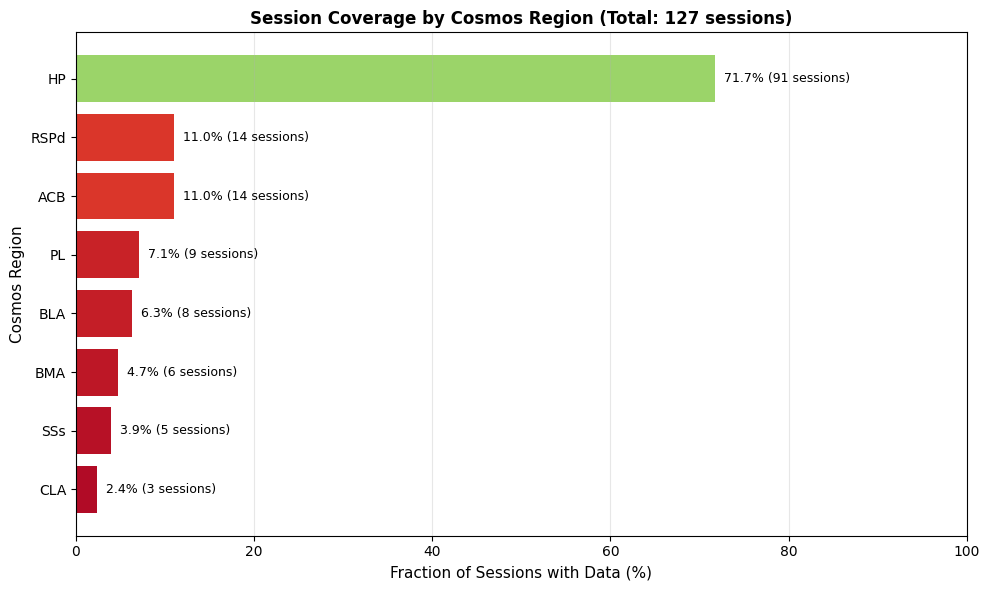

In [44]:
# Plot: Fraction of sessions with data per Cosmos region
fig, ax = plt.subplots(figsize=(10, 6))
coverage_sorted = coverage_df.sort_values('Percent_of_total_sessions')
bars = ax.barh(coverage_sorted['Region'], coverage_sorted['Percent_of_total_sessions'], 
               color=plt.cm.RdYlGn(coverage_sorted['Percent_of_total_sessions'] / 100))
ax.set_xlabel('Fraction of Sessions with Data (%)', fontsize=11)
ax.set_ylabel('Cosmos Region', fontsize=11)
ax.set_title(f'Session Coverage by Cosmos Region (Total: {pivot_table.shape[0]} sessions)', fontsize=12, fontweight='bold')
ax.set_xlim(0, 100)
for i, (region, pct) in enumerate(zip(coverage_sorted['Region'], coverage_sorted['Percent_of_total_sessions'])):
    n_sessions = coverage_sorted['Sessions_with_data'].iloc[i]
    ax.text(pct + 1, i, f'{pct}% ({int(n_sessions)} sessions)', va='center', fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

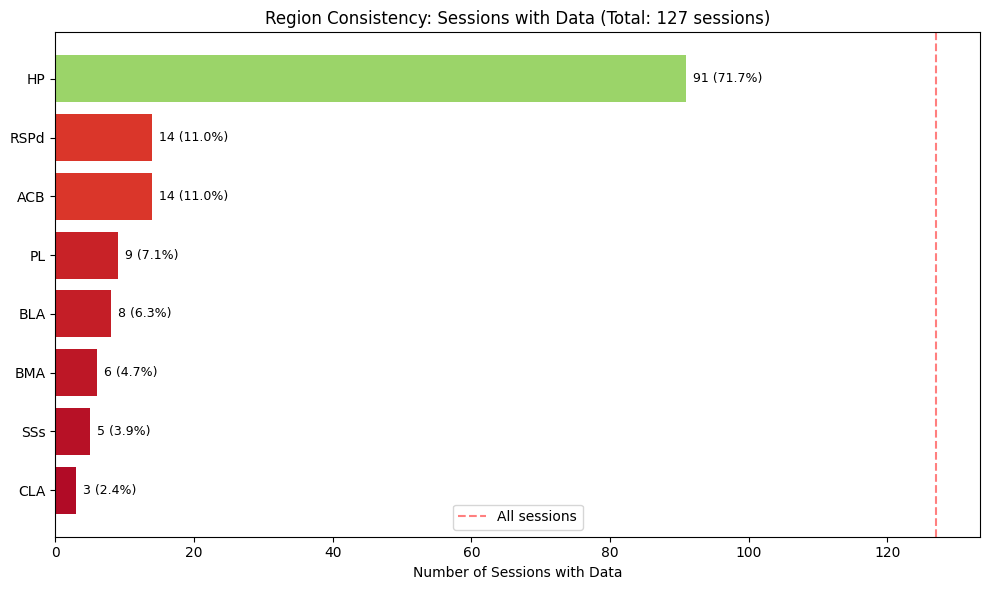

In [45]:
# Bar plot: regions ranked by session coverage
fig, ax = plt.subplots(figsize=(10, 6))
coverage_df_sorted = coverage_df.sort_values('Sessions_with_data')
colors = plt.cm.RdYlGn(coverage_df_sorted['Percent_of_total_sessions'] / 100)
ax.barh(coverage_df_sorted['Region'], coverage_df_sorted['Sessions_with_data'], color=colors)
ax.set_xlabel('Number of Sessions with Data')
ax.set_title(f'Region Consistency: Sessions with Data (Total: {pivot_table.shape[0]} sessions)')
ax.axvline(pivot_table.shape[0], color='red', linestyle='--', alpha=0.5, label='All sessions')
for i, (region, sessions) in enumerate(zip(coverage_df_sorted['Region'], coverage_df_sorted['Sessions_with_data'])):
    pct = coverage_df_sorted['Percent_of_total_sessions'].iloc[i]
    ax.text(sessions + 1, i, f'{int(sessions)} ({pct}%)', va='center', fontsize=9)
ax.legend()
plt.tight_layout()
plt.show()

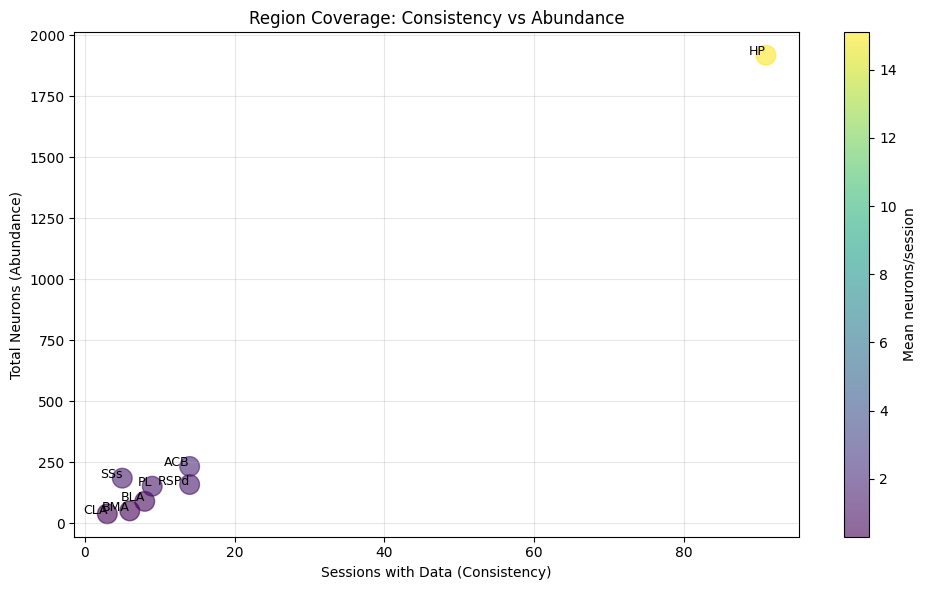

In [46]:
# Scatter: session coverage vs total neurons (identify consistent vs abundant regions)
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(coverage_df['Sessions_with_data'], coverage_df['Total_neurons'], 
                     s=200, alpha=0.6, c=coverage_df['Mean_neurons_per_session'], cmap='viridis')
for i, region in enumerate(coverage_df['Region']):
    ax.annotate(region, 
                (coverage_df['Sessions_with_data'].iloc[i], coverage_df['Total_neurons'].iloc[i]),
                fontsize=9, ha='right')
ax.set_xlabel('Sessions with Data (Consistency)')
ax.set_ylabel('Total Neurons (Abundance)')
ax.set_title('Region Coverage: Consistency vs Abundance')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Mean neurons/session')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

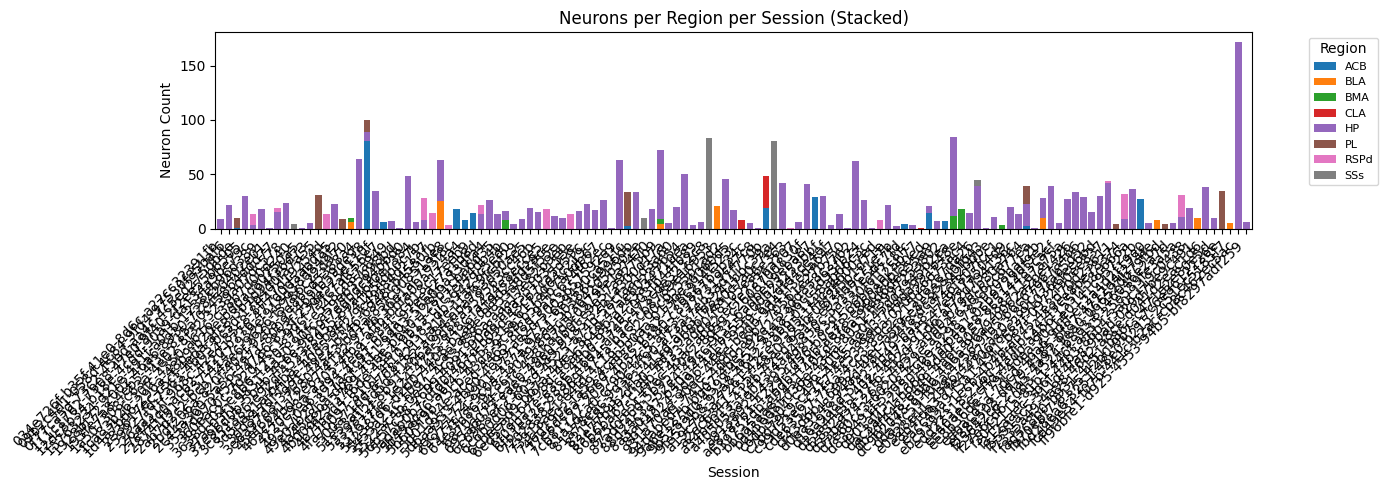

In [47]:
# Stacked bar plot: neurons per region per session
fig, ax = plt.subplots(figsize=(14, 5))
pivot_table.plot(kind='bar', stacked=True, ax=ax, width=0.8)
ax.set_xlabel('Session')
ax.set_ylabel('Neuron Count')
ax.set_title('Neurons per Region per Session (Stacked)')
ax.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

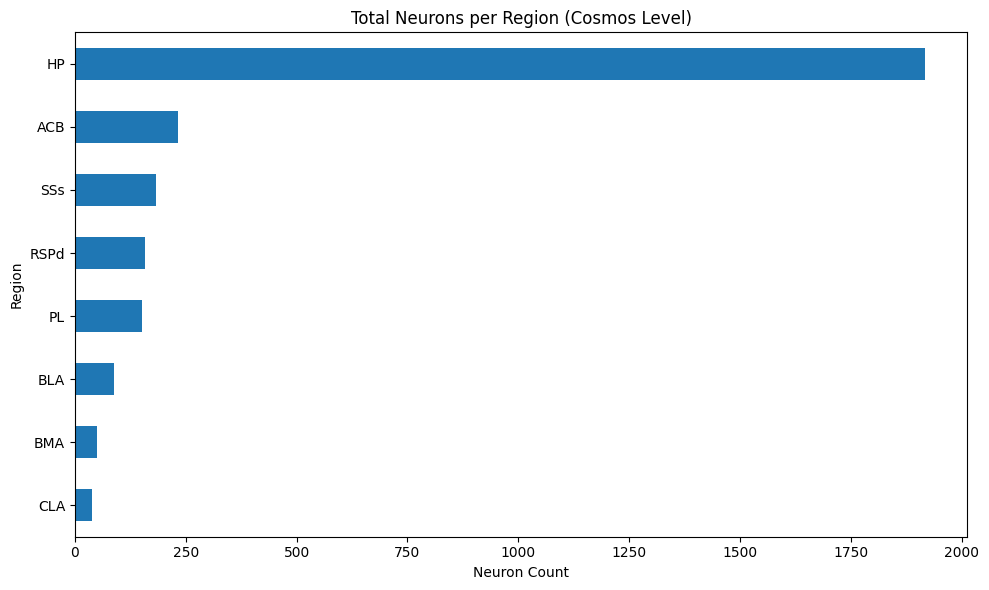

In [48]:
# Bar plot: total neurons per region
fig, ax = plt.subplots(figsize=(10, 6))
stats.set_index('Region')['Count'].sort_values(ascending=True).plot(kind='barh', ax=ax)
ax.set_xlabel('Neuron Count')
ax.set_title(f'Total Neurons per Region (Cosmos Level)')
plt.tight_layout()
plt.show()

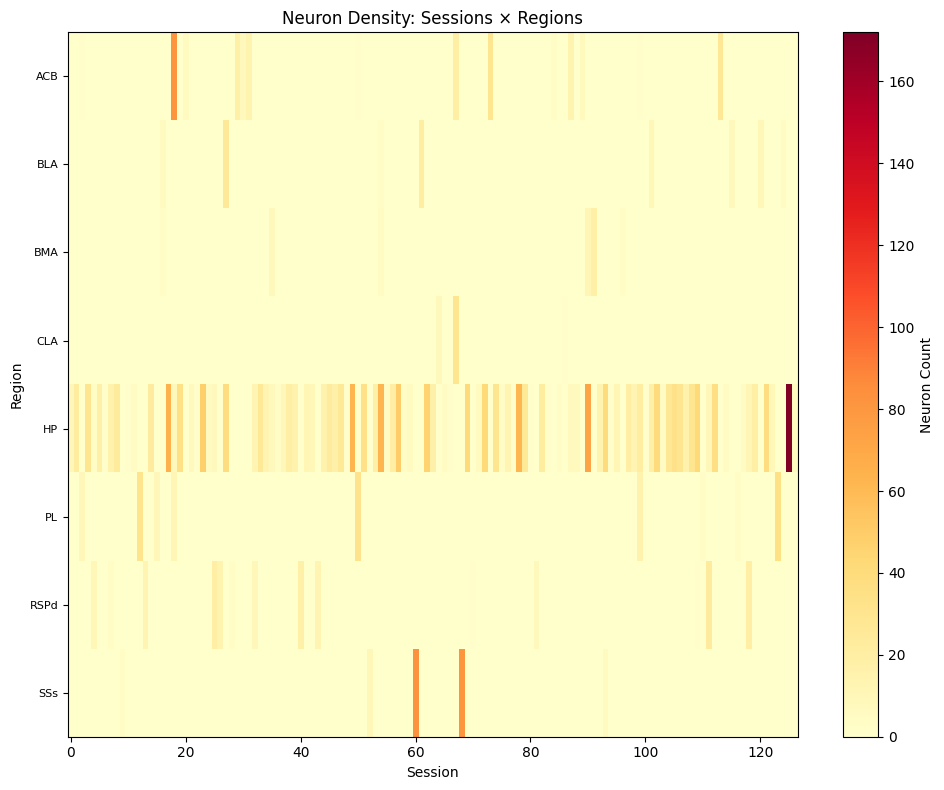

In [49]:
# Heatmap: sessions × regions
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(pivot_table.T, aspect='auto', cmap='YlOrRd', interpolation='nearest')
ax.set_xlabel('Session')
ax.set_ylabel('Region')
ax.set_title('Neuron Density: Sessions × Regions')
plt.colorbar(im, ax=ax, label='Neuron Count')
ax.set_yticks(range(len(pivot_table.columns)))
ax.set_yticklabels(pivot_table.columns, fontsize=8)
plt.tight_layout()
plt.show()

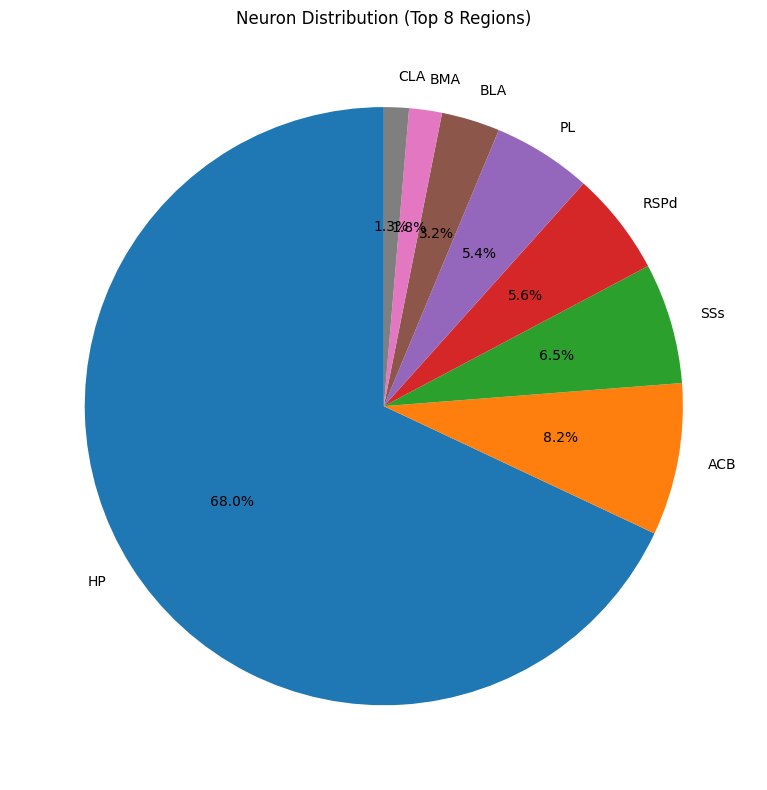

In [50]:
# Pie chart: region composition
fig, ax = plt.subplots(figsize=(10, 8))
top_regions = stats.head(8)  # Top 8 regions
labels = top_regions['Region'].values
sizes = top_regions['Count'].values
ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
ax.set_title('Neuron Distribution (Top 8 Regions)')
plt.tight_layout()
plt.show()